In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [41]:
columns = [
    'ID', 'Clump_Thickness', 'Cell_Size', 'Cell_Shape',
    'Marginal_Adhesion', 'Single_Epithelial_Cell_Size',
    'Bare_Nuclei', 'Bland_Chromatin', 'Normal_Nucleoli',
    'Mitoses', 'Class'
]

df = pd.read_csv('dataset_p1/8breast+cancer+wisconsin+original/breast-cancer-wisconsin.data', names=columns)
print(df.head())
print(df.info())

        ID  Clump_Thickness  Cell_Size  Cell_Shape  Marginal_Adhesion  \
0  1000025                5          1           1                  1   
1  1002945                5          4           4                  5   
2  1015425                3          1           1                  1   
3  1016277                6          8           8                  1   
4  1017023                4          1           1                  3   

   Single_Epithelial_Cell_Size Bare_Nuclei  Bland_Chromatin  Normal_Nucleoli  \
0                            2           1                3                1   
1                            7          10                3                2   
2                            2           2                3                1   
3                            3           4                3                7   
4                            2           1                3                1   

   Mitoses  Class  
0        1      2  
1        1      2  
2        1      2  


In [42]:
# 2 = benigno, 4 = maligno
df['Class'] = df['Class'].map({2: 0, 4: 1})
# en vez de nan hay ?
df.replace('?', np.nan, inplace=True)

#convertimos a numerico
df = df.apply(pd.to_numeric)
# eliminamos nulos
df = df.dropna()
#eliminamos columna irrelevante:
df = df.drop(columns=['ID'])

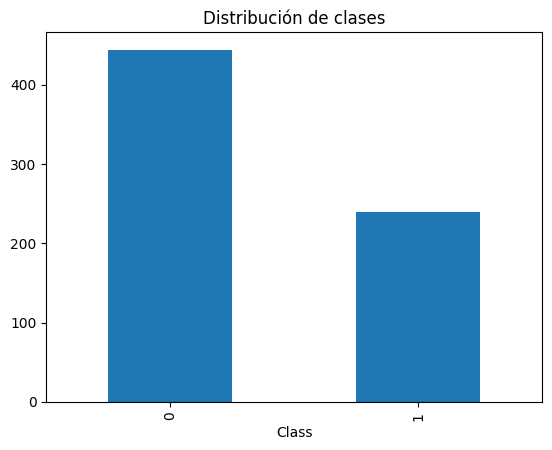

In [43]:
df['Class'].value_counts().plot(kind='bar')
plt.title('Distribución de clases')
plt.show()

In [44]:
corr = df.corr()
print(corr['Class'].sort_values(ascending=False))

Class                          1.000000
Bare_Nuclei                    0.822696
Cell_Shape                     0.821891
Cell_Size                      0.820801
Bland_Chromatin                0.758228
Normal_Nucleoli                0.718677
Clump_Thickness                0.714790
Marginal_Adhesion              0.706294
Single_Epithelial_Cell_Size    0.690958
Mitoses                        0.423448
Name: Class, dtype: float64


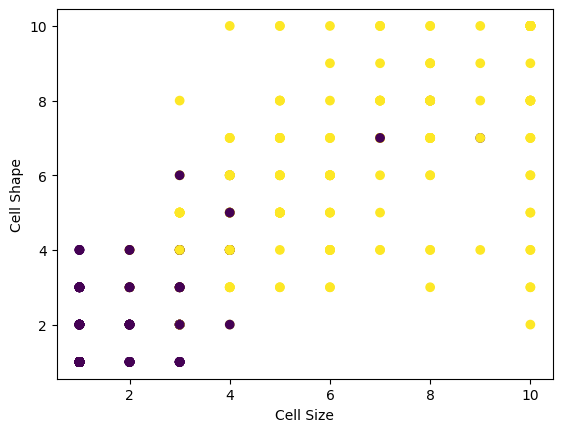

In [45]:
plt.scatter(df['Cell_Size'], df['Cell_Shape'], c=df['Class'])
plt.xlabel('Cell Size')
plt.ylabel('Cell Shape')
plt.show()

In [46]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)
X_train = (X_train - X_train.mean()) / X_train.std()
X_test = (X_test - X_test.mean()) / X_test.std()

In [47]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


In [48]:
weights = np.zeros(X_train.shape[1])
bias = 0
lr = 0.01
epochs = 1000
losses = []

for i in range(epochs):
    z = np.dot(X_train, weights) + bias
    y_pred = sigmoid(z)

    error = y_pred - y_train

    dw = np.dot(X_train.T, error) / len(y_train)
    db = np.sum(error) / len(y_train)

    weights -= lr * dw
    bias -= lr * db

    loss = -np.mean(
        y_train * np.log(y_pred + 1e-8) +
        (1 - y_train) * np.log(1 - y_pred + 1e-8)
    )
    losses.append(loss)

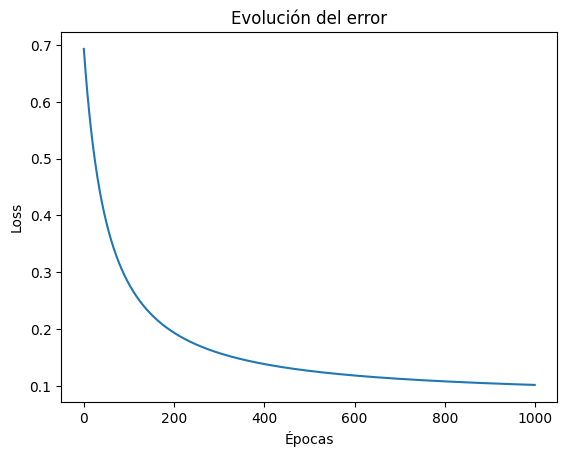

In [49]:
plt.plot(losses)
plt.title('Evolución del error')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.show()

In [50]:
#evaluacion
z_test = np.dot(X_test, weights) + bias
y_pred_test = sigmoid(z_test)

y_pred_class = (y_pred_test >= 0.5).astype(int)
#precision
accuracy = np.mean(y_pred_class == y_test)
print("Accuracy:", accuracy)

#matriz de confuncion
TP = np.sum((y_pred_class == 1) & (y_test == 1))
TN = np.sum((y_pred_class == 0) & (y_test == 0))
FP = np.sum((y_pred_class == 1) & (y_test == 0))
FN = np.sum((y_pred_class == 0) & (y_test == 1))

print("TP:", TP, "TN:", TN, "FP:", FP, "FN:", FN)

Accuracy: 0.9649122807017544
TP: 63 TN: 102 FP: 1 FN: 5
